# Файнтьюнинг Seq2Seq модели для исправления опечаток
**Архитектура:** `Salesforce/codet5-base`  
**Железо:** RTX 4060 Ti (16 GB VRAM) + Bfloat16  
**Подход:** Индустриальный пайплайн с кастомным выводом через `livelossplot`

In [1]:
import os
import torch
import numpy as np
import evaluate
from transformers import (
    AutoTokenizer, 
    T5ForConditionalGeneration, 
    Seq2SeqTrainingArguments, 
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    TrainerCallback
)
from livelossplot import PlotLosses

import sys
sys.path.append(".")
from src.typo_datasets import Seq2SeqTypoDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Обучение на устройстве: {device}")
if device.type == "cuda":
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")

/home/bdbaburin/projects/dl_projects/missprint_proj/llm-for-typo-fixing/llm_seq2seq/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Обучение на устройстве: cuda
Видеокарта: NVIDIA GeForce RTX 4060 Ti


In [2]:
import glob
import os

MODEL_NAME = "Salesforce/codet5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, additional_special_tokens=[])
MAX_LEN = 256


all_data_files = glob.glob("data/data/*/*.jsonl")

train_files = [f for f in all_data_files if "train" in f.lower()]
val_files = [f for f in all_data_files if "val" in f.lower()]

print(f"Найдено файлов для обучения: {len(train_files)}")
print(f"Найдено файлов для валидации: {len(val_files)}")


full_train_dataset = Seq2SeqTypoDataset(train_files, tokenizer, max_length=MAX_LEN)
val_dataset = Seq2SeqTypoDataset(val_files, tokenizer, max_length=MAX_LEN)

import random

if len(val_dataset.data) > 500:
    val_dataset.data = random.sample(val_dataset.data, 500)

def filter_errors_only(dataset):
    return [item for item in dataset.data if item.get("has_errors") and item.get("fixed")]

full_train_dataset.data = filter_errors_only(full_train_dataset)
val_dataset.data = filter_errors_only(val_dataset)

print(f"Примеров с ошибками для обучения: {len(full_train_dataset.data)}")
print(f"Примеров с ошибками для валидации: {len(val_dataset.data)}")

📁 Найдено файлов для обучения: 3
📁 Найдено файлов для валидации: 3
🎯 Примеров с ошибками для обучения: 122574
🎯 Примеров с ошибками для валидации: 416


In [3]:
model = T5ForConditionalGeneration.from_pretrained(
    MODEL_NAME, 
    torch_dtype=torch.bfloat16, 
    weights_only=False 
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, label_pad_token_id=-100)

n_params = sum(p.numel() for p in model.parameters())
print(f"Количество параметров: {n_params / 1e6:.2f}M")

Количество параметров: 222.88M


In [4]:
class LiveLossPlotCallback(TrainerCallback):
    def __init__(self):
        self.plotlosses = PlotLosses(figsize=(12, 10), step_names="Step")
        self.logs = {}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if "loss" in logs:
                self.logs["train_loss"] = logs["loss"]
            if "eval_loss" in logs:
                self.logs["val_loss"] = logs["eval_loss"]
            if "eval_exact_match" in logs:
                self.logs["exact_match"] = logs["eval_exact_match"]
            if "eval_chrf" in logs:
                self.logs["chrf_score"] = logs["eval_chrf"]
            if "eval_bleu" in logs:
                self.logs["bleu_score"] = logs["eval_bleu"]
            
            if state.global_step > 0 and state.global_step % args.logging_steps == 0:
                self.plotlosses.update(self.logs, current_step=state.global_step)
                self.plotlosses.send()

exact_match_metric = evaluate.load("exact_match")
bleu_metric = evaluate.load("sacrebleu")
chrf_metric = evaluate.load("chrf")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]
    
    em_result = exact_match_metric.compute(predictions=decoded_preds, references=decoded_labels)
    references_formatted = [[label] for label in decoded_labels]
    bleu_result = bleu_metric.compute(predictions=decoded_preds, references=references_formatted)
    chrf_result = chrf_metric.compute(predictions=decoded_preds, references=references_formatted)
    
    return {
        "exact_match": em_result.get("exact_match", 0.0),
        "bleu": bleu_result.get("score", 0.0),
        "chrf": chrf_result.get("score", 0.0)
    }

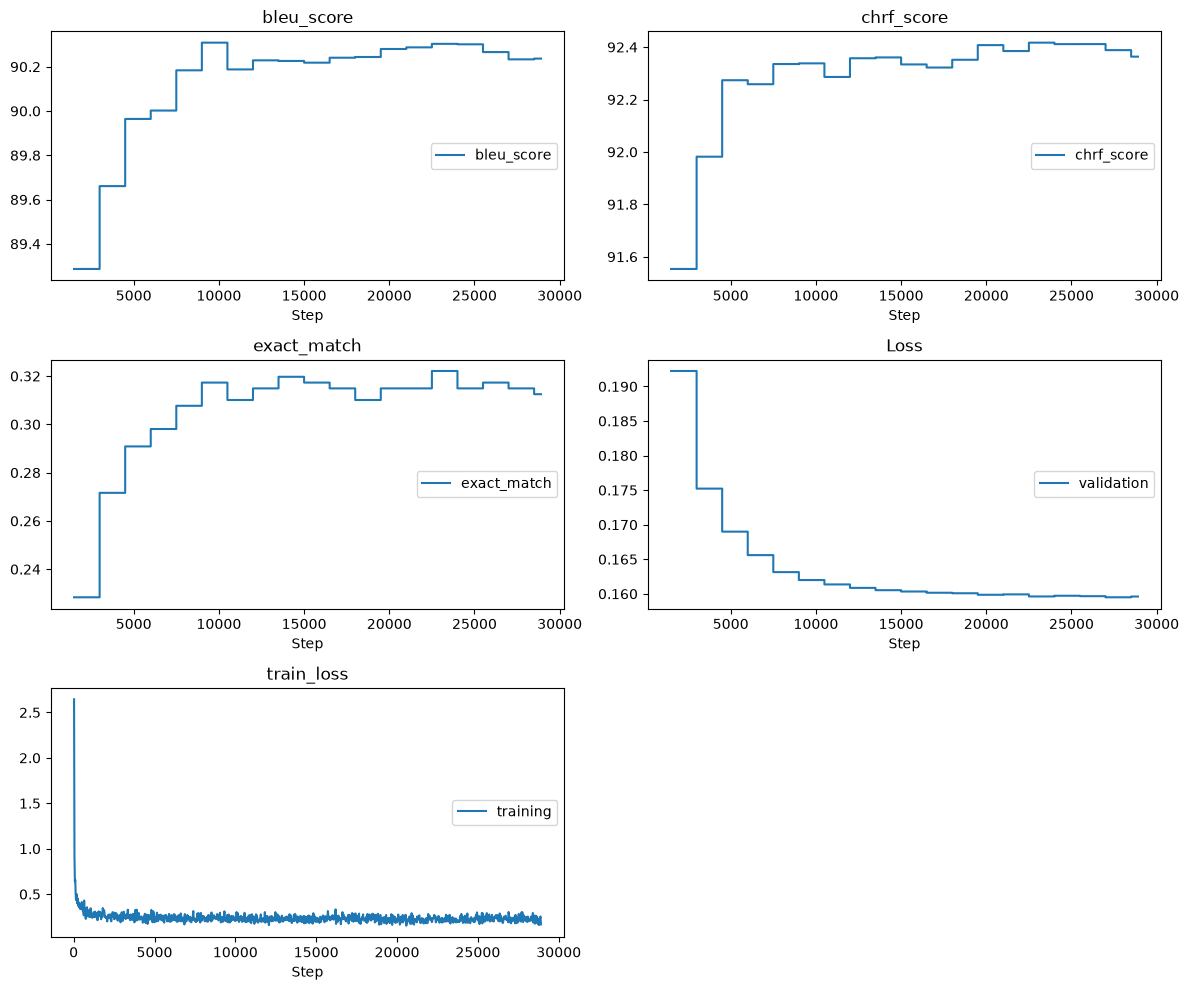

bleu_score
	bleu_score       	 (min:   89.287, max:   90.309, cur:   90.237)
chrf_score
	chrf_score       	 (min:   91.554, max:   92.417, cur:   92.364)
exact_match
	exact_match      	 (min:    0.228, max:    0.322, cur:    0.312)
Loss
	validation       	 (min:    0.159, max:    0.192, cur:    0.160)
train_loss
	training         	 (min:    0.154, max:    2.644, cur:    0.168)


In [ ]:
BATCH_SIZE = 16

training_args = Seq2SeqTrainingArguments(
    output_dir="./codet5-typo-fixer_v2",
    
    eval_strategy="steps",              
    eval_steps=1500,                    
    
    save_strategy="steps",     
    save_steps=1500,        
    
    logging_steps=25,               
    learning_rate=5e-5,
    per_device_train_batch_size=BATCH_SIZE,
    
    per_device_eval_batch_size=BATCH_SIZE, 
    generation_max_length=MAX_LEN,
    generation_num_beams=1,             
    predict_with_generate=True,         
    
    weight_decay=0.01,
    save_total_limit=2,          
    num_train_epochs=5,                
    bf16=True,                          
    report_to="none"                    
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=full_train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[LiveLossPlotCallback()]  
)

print("🚀 Запуск обучения...")
trainer.train()

trainer.save_model("./codet5-typo-fixer-final")
tokenizer.save_pretrained("./codet5-typo-fixer-final")
print("✅ Обучение завершено и модель сохранена!")

In [ ]:
# Забираем кусок грязного кода, который мы отложили для Демо
dirty_code = """def find_Min_Sum(num):
    sum = 0
    i = 2
    while(i * i <= num):
        while(num % i == 0):
            sum += i
            num /= i
        i += 1
    sum += num
    retunr sum"""  # <--- Опечатка в слове return

inputs = tokenizer(dirty_code, return_tensors="pt", max_length=MAX_LEN, truncation=True).to(device)

model.eval()
with torch.inference_mode():
    outputs = model.generate(
        **inputs, 
        max_length=MAX_LEN,
        num_beams=5,             # Beam Search для поиска наилучшего исправления (стандарт для генерации кода)
        early_stopping=True
    )

fixed_code = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("🔴 ИСХОДНЫЙ КОД:")
print(dirty_code)
print("\n" + "="*50 + "\n")
print("🟢 ИСПРАВЛЕННЫЙ КОД:")
print(fixed_code)

🔴 ИСХОДНЫЙ КОД:
def find_Min_Sum(num):
    sum = 0
    i = 2
    while(i * i <= num):
        while(num % i == 0):
            sum += i
            num /= i
        i += 1
    sum += num
    retunr sum


🟢 ИСПРАВЛЕННЫЙ КОД:
def find_min_sum(num):
    sum = 0
    i = 2
    while(i * i <= num):
        while(num % i == 0):
            sum += i
            num /= i
        i += 1
    sum += num
    return sum
